# Summary Statistics UNBIS Thesaurus GA Matching

- 5534 unique resolutions
- 3764 resolutions with subjects (68.02%)
- 1770 resolutions with missing subjects (31.98%)
    - Bias towards older resolutions without subjects (pre-1990s)
    
- Subjects have the form "{Topic}--{Subtopic/Detail}" or "{Topic}|{Topic}". We parse the subjects by splitting on both "--" and "|".
- 400 unique subject entries after splitting.
    - Number of matching subjects between GA data and thesaurus: 240 (48.67%)
- Number of resolutions with at least one subject in thesaurus: 3431 out of 5534 (62.00%)
- Number of resolutions with at least one subject in the thesaurus of the
ones who have subjects: 3431 out of 3764 (91.15%)

- Inconsistent naming:
    - We found a subject 'CLONING OF HUMAN BEINGS--TREATIES (PROPOSED)' that semantically matches 'HUMAN CLONING' in the thesaurus. We assume there to be similar other subjects that we were not able to match due to inconsistent naming conventions.

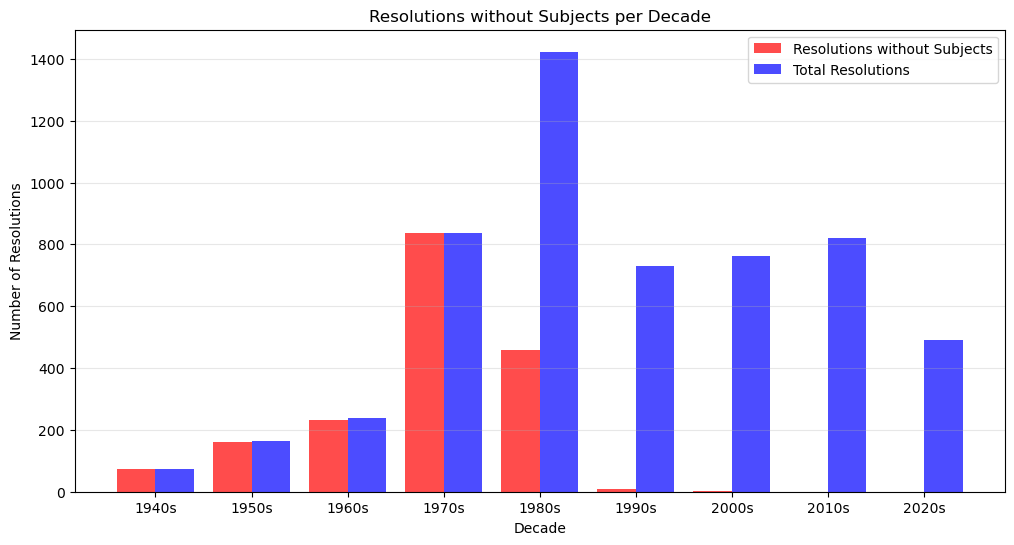

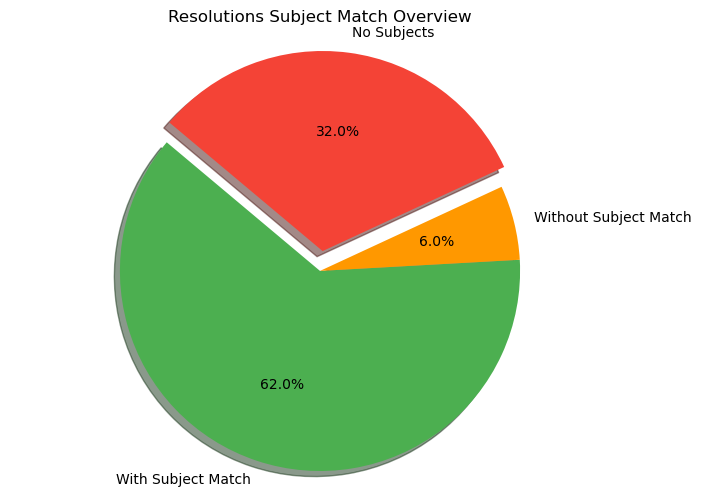

In [109]:
import pandas as pd

df_ga = pd.read_csv("https://digitallibrary.un.org/nanna/record/4060887/files/2025_9_19_ga_voting.csv?withWatermark=0&withMetadata=0&registerDownload=1&version=1")


C:\Users\janic\AppData\Local\Temp\ipykernel_6952\2024198502.py:3: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ga = pd.read_csv("https://digitallibrary.un.org/nanna/record/4060887/files/2025_9_19_ga_voting.csv?withWatermark=0&withMetadata=0&registerDownload=1&version=1")


In [110]:
df_ga.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916554 entries, 0 to 916553
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   undl_id            916554 non-null  int64  
 1   ms_code            916554 non-null  object 
 2   ms_name            916554 non-null  object 
 3   ms_vote            916554 non-null  object 
 4   date               916554 non-null  object 
 5   session            916554 non-null  object 
 6   resolution         916554 non-null  object 
 7   draft              482895 non-null  object 
 8   committee_report   730230 non-null  object 
 9   meeting            916554 non-null  object 
 10  title              916554 non-null  object 
 11  agenda_title       904305 non-null  object 
 12  subjects           681736 non-null  object 
 13  vote_note          359 non-null     object 
 14  total_yes          916554 non-null  float64
 15  total_no           916554 non-null  float64
 16  to

In [111]:
# change df to one row per resolution 
df_ga['session'] = df_ga['session'].astype(str) # else we get some duplicate


ga_index_columns = ["undl_id", "date", "session", "resolution", "draft", "committee_report", "meeting", "title", "agenda_title", "subjects", "total_yes", "total_no", "total_abstentions", "total_non_voting", "total_ms", "undl_link"]
df_ga_res = df_ga.pivot(index=ga_index_columns, columns='ms_code', values='ms_vote').reset_index()
df_ga_res.columns.name = None

In [112]:
print(f"{df_ga_res['resolution'].nunique()} unique resolutions")

5534 unique resolutions


In [113]:
num_missing_subjects = len(df_ga_res[df_ga_res['subjects'].isna()])
percent_missing_subjects = (num_missing_subjects / df_ga_res.shape[0]) * 100
print(f"{df_ga_res.shape[0] - num_missing_subjects} resolutions with subjects ({100 - percent_missing_subjects:.2f}%)")
print(f"{num_missing_subjects} resolutions with missing subjects ({percent_missing_subjects:.2f}%)")

3764 resolutions with subjects (68.02%)
1770 resolutions with missing subjects (31.98%)


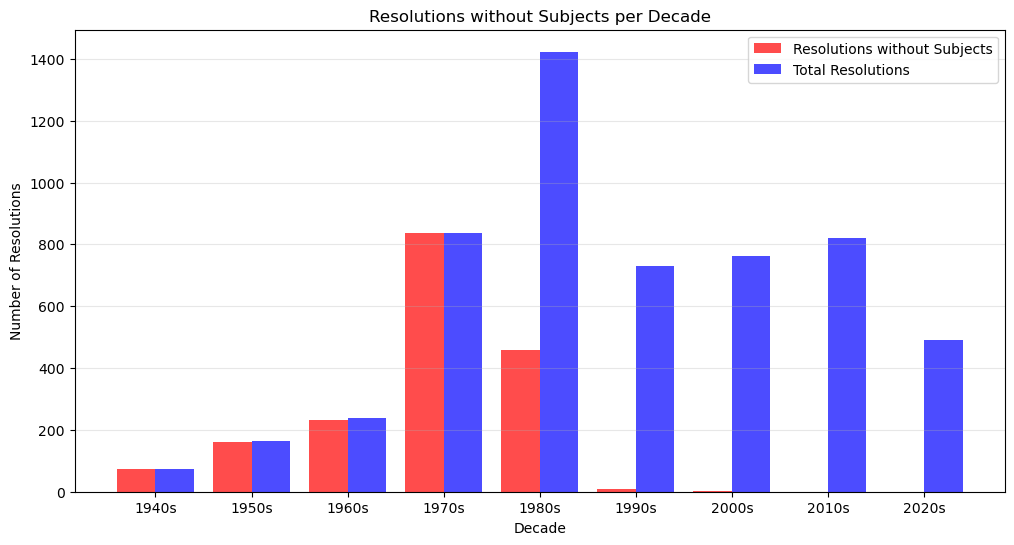

In [114]:
import matplotlib.pyplot as plt

# Convert date to datetime
df_ga_res['date'] = pd.to_datetime(df_ga_res['date'])

# Extract year and create decade bins
df_ga_res['year'] = df_ga_res['date'].dt.year
df_ga_res['decade'] = (df_ga_res['year'] // 10) * 10

# Count resolutions without subjects per decade
missing_subjects_per_decade = df_ga_res[df_ga_res['subjects'].isna()].groupby('decade').size()
total_resolutions_per_decade = df_ga_res.groupby('decade').size()

# Create bar plot with bars side by side
plt.figure(figsize=(12, 6))
width = 4  # width of bars
x = total_resolutions_per_decade.index

plt.bar(missing_subjects_per_decade.index - width/2, missing_subjects_per_decade.values, width, alpha=0.7, color='red', label='Resolutions without Subjects')
plt.bar(x + width/2, total_resolutions_per_decade.values, width, alpha=0.7, color='blue', label='Total Resolutions')

plt.xlabel('Decade')
plt.ylabel('Number of Resolutions')
plt.title('Resolutions without Subjects per Decade')
plt.xticks(x, [f"{d}s" for d in x])
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

In [115]:
print(f"{df_ga_res['subjects'].nunique()} unique subject combinations")
print("\nMost common subjects")
print(df_ga_res['subjects'].value_counts().head(10))

442 unique subject combinations

Most common subjects
subjects
DISARMAMENT--GENERAL AND COMPLETE                        243
TERRITORIES OCCUPIED BY ISRAEL--HUMAN RIGHTS--REPORTS    208
UNRWA--ACTIVITIES                                        200
PALESTINE QUESTION                                       169
DECOLONIZATION                                           104
HUMAN RIGHTS ADVANCEMENT                                 102
MIDDLE EAST SITUATION                                     98
APARTHEID                                                 75
UN. ECONOMIC AND SOCIAL COUNCIL--REPORTS                  68
SELF-DETERMINATION OF PEOPLES                             62
Name: count, dtype: int64


In [116]:
# Split based on | and --
df_ga_res['subject_list'] = df_ga_res['subjects'].str.split(r'\||--')
subject_list = df_ga_res['subject_list'].explode().str.strip()

print(f"{len(subject_list.unique())} total unique subject entries after splitting")
print("\nSample subjects:")
print(pd.DataFrame(subject_list).value_counts().head(10))

400 total unique subject entries after splitting

Sample subjects:
subject_list                  
REPORTS                           528
HUMAN RIGHTS                      478
DISARMAMENT                       430
TERRITORIES OCCUPIED BY ISRAEL    274
GENERAL AND COMPLETE              254
HUMAN RIGHTS ADVANCEMENT          254
UNRWA                             218
ACTIVITIES                        201
DECOLONIZATION                    183
PALESTINE QUESTION                172
Name: count, dtype: int64


In [117]:
# Load the thesaurus

df_thesaurus = pd.read_csv("C:\\Users\\janic\\OneDrive\\Desktop\\ETH\\UN Projekt\\data\\unbist-20250708.csv")
df_thesaurus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43927 entries, 0 to 43926
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   uri        43927 non-null  object
 1   prefLabel  43927 non-null  object
dtypes: object(2)
memory usage: 686.5+ KB


In [118]:
thesaurus_labels = df_thesaurus['prefLabel'].unique()
print(f"{len(thesaurus_labels)} unique thesaurus labels")
print("\nSample thesaurus labels:")
print(pd.DataFrame(thesaurus_labels).sample(10, random_state=42))

42675 unique thesaurus labels

Sample thesaurus labels:
                                          0
12457                                    矿工
354    DECOLONISATION, TUTELLE ET APARTHEID
11680                FERTILITY DISTRIBUTION
36143       Лидерство в местных сообществах
34102                        HOUSEHOLD DEBT
42636                        домогательство
13757                           朝鲜民主主义人民共和国
2055                 SINO-TIBETAN LANGUAGES
23368               ECONOMIA DEL TRANSPORTE
40505                                Тюрьмы


In [119]:
# Check for the subjects in the thesaurus

# Convert both array to sets
ga_subjects_set = set(subject_list.dropna().unique())
thesaurus_set = set(thesaurus_labels)

In [120]:
# Find matches
matches = ga_subjects_set.intersection(thesaurus_set)
num_matches = len(matches)
percent_matched_subjects = (num_matches / len(ga_subjects_set)) * 100
print(f"Number of matching subjects between GA data and thesaurus: {num_matches} ({percent_missing_subjects:.2f}%)")
print("\nSample matched subjects:")
print(pd.DataFrame(list(matches)).sample(10, random_state=42))

print(f"Number of GA subjects not in thesaurus: {len(ga_subjects_set) - num_matches}")
print("\nSample non-matched GA subjects:")
print(pd.DataFrame(list(ga_subjects_set - matches)).sample(10, random_state=42))

Number of matching subjects between GA data and thesaurus: 240 (31.98%)

Sample matched subjects:
                               0
24                   MERCENARIES
6                    RESTITUTION
93   FALKLAND ISLANDS (MALVINAS)
109     PROGRAMME IMPLEMENTATION
104          NUCLEAR DISARMAMENT
172                      CROATIA
233          DUAL-USE TECHNOLOGY
86                  INDEPENDENCE
9                RECOMMENDATIONS
143                OLYMPIC GAMES
Number of GA subjects not in thesaurus: 159

Sample non-matched GA subjects:
                                                     0
78            UN COMMISSION ON INTERNATIONAL TRADE LAW
155      UN. GENERAL ASSEMBLY (15TH SESS. : 1960-1961)
128                            CLONING OF HUMAN BEINGS
55   UN. GENERAL ASSEMBLY (66TH SESS. : 2011-2012)....
94                                      PLAN OF ACTION
29                                   CONVENTIONAL ARMS
147                                          CESSATION
51                    

In [121]:
# Now we check for each resolution if at least one is in the thesaurus

thesaurus_check = lambda subjects: any(subj.strip() in thesaurus_set for subj in subjects) if isinstance(subjects, list) else False

df_ga_res['subject_in_thesaurus'] = df_ga_res['subject_list'].apply(thesaurus_check)

num_res_with_match = df_ga_res['subject_in_thesaurus'].sum()
percent_res_with_match = (num_res_with_match / df_ga_res.shape[0]) * 100
print(f"Number of resolutions with at least one subject in thesaurus: {num_res_with_match} ({percent_res_with_match:.2f}%)")

num_res_with_subj = df_ga_res.shape[0] - num_missing_subjects
percent_res_with_match_with_subj = (num_res_with_match / num_res_with_subj) * 100
print(f"Number of resolutions with at least one subject in the thesaurus of the\nones who have subjects: {num_res_with_match} out of {num_res_with_subj} ({percent_res_with_match_with_subj:.2f}%)")


Number of resolutions with at least one subject in thesaurus: 3431 (62.00%)
Number of resolutions with at least one subject in the thesaurus of the
ones who have subjects: 3431 out of 3764 (91.15%)


In [122]:
df_ga_no_subj_match = df_ga_res[(df_ga_res['subject_in_thesaurus'] == False) & (df_ga_res['subjects'].notna())]
print("\nSample resolutions with no subject match:")
print(df_ga_no_subj_match[['resolution', 'subjects']].sample(10, random_state=42))


Sample resolutions with no subject match:
           resolution                                           subjects
209       A/RES/39/90            MULTILATERAL TREATIES--DRAFTING PROCESS
5412     A/RES/78/283  ORGANIZATION FOR DEMOCRACY AND ECONOMIC DEVELO...
525      A/RES/41/69G                                              UNRWA
2191      A/RES/61/88             CENTRAL ASIAN--UCLEAR-WEAPON-FREE ZONE
422      A/RES/40/170           UN. ECONOMIC AND SOCIAL COUNCIL--REPORTS
5315    A/RES/77/263A                                  UN--BUDGET (2023)
5141  A/RES/75/254[C]                                  UN--BUDGET (2021)
1811      A/RES/56/49  PREPARATORY COMMISSION FOR THE COMPREHENSIVE N...
4211  A/RES/40/257[A]                             UN--BUDGET (1986-1987)
2248     A/RES/61/295                  UN. HUMAN RIGHTS COUNCIL--REPORTS


In [123]:
# get most common non-matching subjects
print("\nMost common non-matching subjects:")
print(df_ga_no_subj_match['subjects'].value_counts().head(10))


Most common non-matching subjects:
subjects
UN. ECONOMIC AND SOCIAL COUNCIL--REPORTS                      68
UN. HUMAN RIGHTS COUNCIL--REPORTS                             20
ORGANIZATION FOR DEMOCRACY AND ECONOMIC DEVELOPMENT - GUAM    19
UNRWA                                                         18
UN--BUDGET (1986-1987)                                        18
IAEA--REPORTS                                                 16
UN--BUDGET (1984-1985)                                        15
UN CONFERENCES                                                12
LEAGUE OF ARAB STATES--UN                                     11
ARMED CONFLICTS PREVENTION                                    10
Name: count, dtype: int64


In [124]:
print("\nMost common non-matching individual subjects:")
print(df_ga_no_subj_match['subject_list'].explode().value_counts().head(10))


Most common non-matching individual subjects:
subject_list
REPORTS                                                       127
UN                                                             98
UN. ECONOMIC AND SOCIAL COUNCIL                                68
UN. HUMAN RIGHTS COUNCIL                                       20
ORGANIZATION FOR DEMOCRACY AND ECONOMIC DEVELOPMENT - GUAM     19
BUDGET (1986-1987)                                             18
UNRWA                                                          18
IAEA                                                           16
BUDGET (1984-1985)                                             15
UN CONFERENCES                                                 13
Name: count, dtype: int64


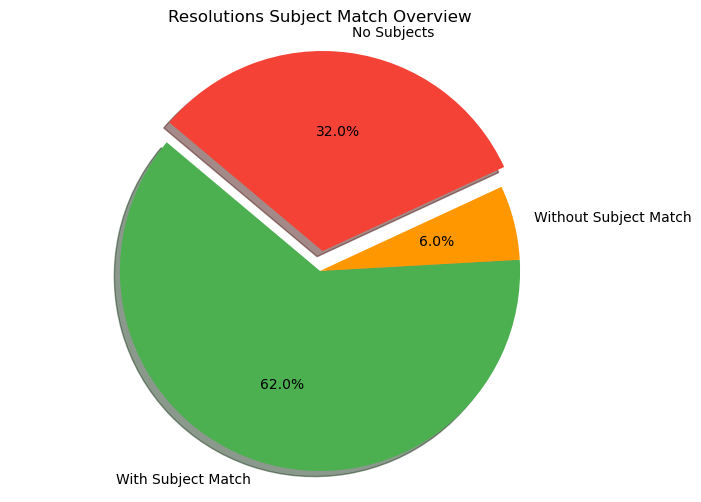

In [127]:
# We make a pie plot for showing how many resolutions can be used
num_res_with_match = df_ga_res['subject_in_thesaurus'].sum()
num_res_without_match = num_res_with_subj - num_res_with_match
num_res_without_subj = num_missing_subjects

import matplotlib.pyplot as plt
labels = ['With Subject Match', 'Without Subject Match', 'No Subjects']
sizes = [num_res_with_match, num_res_without_match, num_res_without_subj]
colors = ['#4CAF50', '#FF9800', '#F44336']
explode = (0, 0, 0.1)  # explode the first slice
plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Resolutions Subject Match Overview')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()



## Further parsing strategies and other additional analysis


In [99]:
# parse | and then take first if --
parse = lambda subj: subj.split('--')[0].strip() if '--' in subj else subj.strip()
df_ga_res['subject_list'] = df_ga_res['subjects'].str.split('|').apply(lambda subjects: [parse(subj) for subj in subjects] if isinstance(subjects, list) else [])
subject_list = df_ga_res['subject_list'].explode().str.strip()

print(f"{len(subject_list.unique())} total unique subject entries after splitting")
print("\nSample subjects:")
print(pd.DataFrame(subject_list).value_counts().head(10))

255 total unique subject entries after splitting

Sample subjects:
subject_list                   
DISARMAMENT                        403
TERRITORIES OCCUPIED BY ISRAEL     274
HUMAN RIGHTS ADVANCEMENT           254
HUMAN RIGHTS                       232
UNRWA                              218
DECOLONIZATION                     183
PALESTINE QUESTION                 172
MIDDLE EAST SITUATION              101
UN. ECONOMIC AND SOCIAL COUNCIL     89
SELF-DETERMINATION OF PEOPLES       82
Name: count, dtype: int64


In [100]:
# Check for the subjects in the thesaurus

# Convert both array to sets
ga_subjects_set = set(subject_list.dropna().unique())
thesaurus_set = set(thesaurus_labels)

In [101]:
# Find matches
matches = ga_subjects_set.intersection(thesaurus_set)
num_matches = len(matches)
percent_matched_subjects = (num_matches / len(ga_subjects_set)) * 100
print(f"Number of matching subjects between GA data and thesaurus: {num_matches} ({percent_missing_subjects:.2f}%)")
print("\nSample matched subjects:")
print(pd.DataFrame(list(matches)).sample(10, random_state=42))

print(f"Number of GA subjects not in thesaurus: {len(ga_subjects_set) - num_matches}")
print("\nSample non-matched GA subjects:")
print(pd.DataFrame(list(ga_subjects_set - matches)).sample(10, random_state=42))

Number of matching subjects between GA data and thesaurus: 178 (31.98%)

Sample matched subjects:
                                 0
19                           YOUTH
45                         CLIMATE
140        AMERICAN SAMOA QUESTION
30                 MULTILATERALISM
67                     INFORMATION
16                     MERCENARIES
119  COORDINATION WITHIN UN SYSTEM
174                    NUCLEAR WAR
109          FISSIONABLE MATERIALS
141                         SPORTS
Number of GA subjects not in thesaurus: 76

Sample non-matched GA subjects:
                                           0
4                       AZERBAIJAN SITUATION
35                       SOUTHERN HEMISPHERE
10         UN HIGH COMMISSIONER FOR REFUGEES
0   UN COMMISSION ON INTERNATIONAL TRADE LAW
45                                    UNIFIL
47                    LIBYAN ARAB JAMAHIRIYA
65                         CONVENTIONAL ARMS
53          NUCLEAR DISARMAMENT NEGOTIATIONS
50                           SOUTH-E

In [102]:
# Now we check for each resolution if at least one is in the thesaurus

thesaurus_check = lambda subjects: any(subj.strip() in thesaurus_set for subj in subjects) if isinstance(subjects, list) else False

df_ga_res['subject_in_thesaurus'] = df_ga_res['subject_list'].apply(thesaurus_check)

num_res_with_match = df_ga_res['subject_in_thesaurus'].sum()
percent_res_with_match = (num_res_with_match / df_ga_res.shape[0]) * 100
print(f"Number of resolutions with at least one subject in thesaurus: {num_res_with_match} ({percent_res_with_match:.2f}%)")

num_res_with_subj = df_ga_res.shape[0] - num_missing_subjects
percent_res_with_match_with_subj = (num_res_with_match / num_res_with_subj) * 100
print(f"Number of resolutions with at least one subject in the thesaurus of the\nones who have subjects: {num_res_with_match} out of {num_res_with_subj} ({percent_res_with_match_with_subj:.2f}%)")


Number of resolutions with at least one subject in thesaurus: 3089 (55.82%)
Number of resolutions with at least one subject in the thesaurus of the
ones who have subjects: 3089 out of 3764 (82.07%)


In [103]:
df_ga_no_subj_match = df_ga_res[(df_ga_res['subject_in_thesaurus'] == False) & (df_ga_res['subjects'].notna())]
print("\nSample resolutions with no subject match:")
print(df_ga_no_subj_match[['resolution', 'subjects']].sample(10, random_state=42))


Sample resolutions with no subject match:
        resolution                                           subjects
2343  A/RES/62/190                AGENDA 21--PROGRAMME IMPLEMENTATION
1649   A/RES/54/26                                      IAEA--REPORTS
5530  A/RES/79/331  INTERNATIONAL ORGANIZATION OF LA FRANCOPHONIE--UN
4840  A/RES/72/299             UN INTERIM FORCE IN LEBANON--FINANCING
2179   A/RES/61/69     SOUTHERN HEMISPHERE--NUCLEAR-WEAPON-FREE ZONES
330   A/RES/40/80A                                  NUCLEAR TEST BANS
5413  A/RES/78/305             UN INTERIM FORCE IN LEBANON--FINANCING
1322   A/RES/49/58                                UN CHARTER--REPORTS
5511  A/RES/79/283                                     UN CONFERENCES
4501  A/RES/68/262              ARMED CONFLICTS PREVENTION--MEDIATION


In [104]:
# get most common non-matching subjects
print("\nMost common non-matching subjects:")
print(df_ga_no_subj_match['subjects'].value_counts().head(10))


Most common non-matching subjects:
subjects
UNRWA--ACTIVITIES                                             200
UN. ECONOMIC AND SOCIAL COUNCIL--REPORTS                       68
UN INTERIM FORCE IN LEBANON--FINANCING                         39
CONVENTIONAL ARMS--REGIONAL PROGRAMMES                         23
UN. HUMAN RIGHTS COUNCIL--REPORTS                              20
ORGANIZATION FOR DEMOCRACY AND ECONOMIC DEVELOPMENT - GUAM     19
UNRWA                                                          18
UN--BUDGET (1986-1987)                                         18
SOUTHERN HEMISPHERE--NUCLEAR-WEAPON-FREE ZONES                 16
IAEA--REPORTS                                                  16
Name: count, dtype: int64


In [105]:
print("\nMost common non-matching individual subjects:")
print(df_ga_no_subj_match['subject_list'].explode().value_counts().head(10))


Most common non-matching individual subjects:
subject_list
UNRWA                                                         218
UN. ECONOMIC AND SOCIAL COUNCIL                                68
UN                                                             56
UN INTERIM FORCE IN LEBANON                                    39
CONVENTIONAL ARMS                                              23
UN. HUMAN RIGHTS COUNCIL                                       20
ORGANIZATION FOR DEMOCRACY AND ECONOMIC DEVELOPMENT - GUAM     19
UN CONFERENCES                                                 18
IAEA                                                           16
SOUTHERN HEMISPHERE                                            16
Name: count, dtype: int64


In [107]:
# Filter subjects that contain 'cloning' (case-insensitive)
cloning_subjects = df_ga_res[df_ga_res['subjects'].str.contains('cloning', case=False, na=False)]
print(f"Found {len(cloning_subjects)} resolutions with 'cloning' in subjects\n")
print(cloning_subjects[['resolution', 'title', 'subjects']].to_string())

Found 1 resolutions with 'cloning' in subjects

        resolution                                                                                       title                                      subjects
2079  A/RES/59/280  United Nations declaration on human cloning : resolution / adopted by the General Assembly  CLONING OF HUMAN BEINGS--TREATIES (PROPOSED)


In [ ]:
resolution_counts = df_ga_res['resolution'].value_counts()
duplicate_resolutions = resolution_counts[resolution_counts > 1]
print(f"{len(duplicate_resolutions)} resolutions appear more than once")
print(duplicate_resolutions)

4 resolutions appear more than once
resolution
A/RES/62/83     2
A/RES/52/143    2
A/RES/48/82     2
A/RES/41/60A    2
Name: count, dtype: int64


In [ ]:
# Look at all duplicate resolutions in detail
for res in duplicate_resolutions.index:
    print(f"\n{'='*80}")
    print(f"Resolution: {res}")
    print(f"{'='*80}")
    
    # Get all rows for this resolution
    duplicate_rows = df_ga_res[df_ga_res['resolution'] == res]
    
    # Compare the index columns first
    print("\nIndex columns comparison:")
    for col in ga_index_columns:
        unique_vals = duplicate_rows[col].unique()
        if len(unique_vals) > 1:
            print(f"  {col}: DIFFERENT")
            for idx, row in duplicate_rows.iterrows():
                print(f"    Row {idx}: {row[col]}")
        #else:
            #print(f"  {col}: same ({unique_vals[0]})")
    
    # Check voting columns for differences
    voting_cols = [col for col in duplicate_rows.columns if col not in ga_index_columns]
    different_voting_cols = []
    for col in voting_cols:
        if duplicate_rows[col].nunique() > 1:
            different_voting_cols.append(col)
    
    if different_voting_cols:
        print(f"\n{len(different_voting_cols)} country votes differ:")
        print(f"  {', '.join(different_voting_cols[:10])}", end="")
        if len(different_voting_cols) > 10:
            print(f" ... and {len(different_voting_cols) - 10} more")
        else:
            print()


Resolution: A/RES/62/83

Index columns comparison:
  session: DIFFERENT
    Row 2308: 62
    Row 2309: 62

Resolution: A/RES/52/143

Index columns comparison:
  session: DIFFERENT
    Row 1580: 52
    Row 1581: 52

Resolution: A/RES/48/82

Index columns comparison:
  session: DIFFERENT
    Row 1273: 48
    Row 1274: 48

Resolution: A/RES/41/60A

Index columns comparison:
  session: DIFFERENT
    Row 504: 41
    Row 505: 41
